In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/predict-salary-for-data-science-jobs/muestra.csv
/kaggle/input/predict-salary-for-data-science-jobs/salaries_data.csv
/kaggle/input/predict-salary-for-data-science-jobs/testeo.csv


### Read files

In [2]:
submission = pd.read_csv("/kaggle/input/predict-salary-for-data-science-jobs/muestra.csv")
test = pd.read_csv("/kaggle/input/predict-salary-for-data-science-jobs/testeo.csv")
train = pd.read_csv("/kaggle/input/predict-salary-for-data-science-jobs/salaries_data.csv")

In [3]:
train

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2022,SE,FT,Data Engineer,140250,USD,140250,US,100,US,M
1,2022,SE,FT,Data Engineer,135000,USD,135000,US,100,US,M
2,2021,MI,FT,BI Data Analyst,100000,USD,100000,US,100,US,M
3,2021,MI,CT,ML Engineer,270000,USD,270000,US,100,US,L
4,2021,MI,FT,Data Engineer,22000,EUR,26005,RO,0,US,L
...,...,...,...,...,...,...,...,...,...,...,...
495,2022,SE,FT,Data Engineer,100000,USD,100000,US,100,US,M
496,2021,EN,FT,Big Data Engineer,435000,INR,5882,IN,0,CH,L
497,2022,SE,FT,Data Architect,90700,USD,90700,CA,100,CA,M
498,2021,MI,FT,Data Engineer,60000,GBP,82528,GB,100,GB,L


In [4]:
train.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,500.000000,5.000000e+02,500.000000,500.000000
mean,2021.414000,3.342164e+05,112996.216000,71.800000
std,0.683768,1.626526e+06,69613.750601,40.472658
min,2020.000000,4.000000e+03,2859.000000,0.000000
25%,2021.000000,7.000000e+04,64594.500000,50.000000
50%,2022.000000,1.140000e+05,103080.000000,100.000000
75%,2022.000000,1.600800e+05,150000.000000,100.000000
max,2022.000000,3.040000e+07,450000.000000,100.000000


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           500 non-null    int64 
 1   experience_level    500 non-null    object
 2   employment_type     500 non-null    object
 3   job_title           500 non-null    object
 4   salary              500 non-null    int64 
 5   salary_currency     500 non-null    object
 6   salary_in_usd       500 non-null    int64 
 7   employee_residence  500 non-null    object
 8   remote_ratio        500 non-null    int64 
 9   company_location    500 non-null    object
 10  company_size        500 non-null    object
dtypes: int64(4), object(7)
memory usage: 43.1+ KB


In [6]:
train.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [7]:
train = train.drop(['salary', 'salary_currency' ], axis=1)
train

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2022,SE,FT,Data Engineer,140250,US,100,US,M
1,2022,SE,FT,Data Engineer,135000,US,100,US,M
2,2021,MI,FT,BI Data Analyst,100000,US,100,US,M
3,2021,MI,CT,ML Engineer,270000,US,100,US,L
4,2021,MI,FT,Data Engineer,26005,RO,0,US,L
...,...,...,...,...,...,...,...,...,...
495,2022,SE,FT,Data Engineer,100000,US,100,US,M
496,2021,EN,FT,Big Data Engineer,5882,IN,0,CH,L
497,2022,SE,FT,Data Architect,90700,CA,100,CA,M
498,2021,MI,FT,Data Engineer,82528,GB,100,GB,L


In [8]:
train.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [9]:
test

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
0,2020,SE,FT,Machine Learning Scientist,JP,0,JP,S
1,2020,MI,FT,Lead Data Analyst,US,100,US,L
2,2020,MI,FT,Data Analyst,US,100,US,L
3,2020,MI,FT,Machine Learning Engineer,CN,0,CN,M
4,2020,MI,FT,Product Data Analyst,IN,100,IN,L
...,...,...,...,...,...,...,...,...
102,2022,SE,FT,Data Analyst,US,100,US,M
103,2022,SE,FT,Data Architect,US,100,US,M
104,2022,SE,FT,Data Scientist,US,100,US,M
105,2022,EN,FT,Data Analyst,CA,0,CA,M


In [10]:
test.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')

In [11]:
test.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [12]:
submission

,id,salary_in_usd
0,0,26352
1,1,40574
2,2,68759
3,3,74733
4,4,32611
...,...,...
102,102,83373
103,103,57827
104,104,31053
105,105,39725


### Analyse train

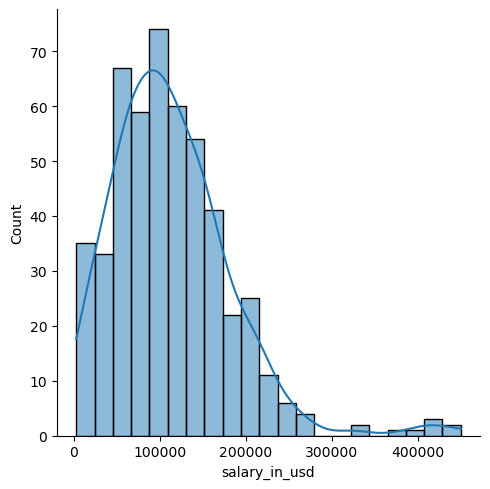

In [13]:
sns.displot(train['salary_in_usd'], kde=True)

In [14]:
train['salary_in_usd'].value_counts()

100000    12
150000    10
135000     9
200000     9
120000     9
          ..
230000     1
173762     1
91237      1
18907      1
90700      1
Name: salary_in_usd, Length: 312, dtype: int64

In [15]:
is_multi = train["salary_in_usd"].value_counts() > 1
filtered = train[train["salary_in_usd"].isin(is_multi[is_multi].index)]
train = filtered
train

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
1,2022,SE,FT,Data Engineer,135000,US,100,US,M
2,2021,MI,FT,BI Data Analyst,100000,US,100,US,M
5,2022,MI,FT,Machine Learning Scientist,153000,US,50,US,M
8,2022,MI,FT,Data Engineer,76940,GR,100,GR,M
9,2021,EN,FT,Data Analyst,59102,FR,50,FR,M
...,...,...,...,...,...,...,...,...,...
493,2022,SE,FT,Data Engineer,180000,US,100,US,M
494,2022,SE,FT,Data Scientist,144000,US,100,US,M
495,2022,SE,FT,Data Engineer,100000,US,100,US,M
498,2021,MI,FT,Data Engineer,82528,GB,100,GB,L


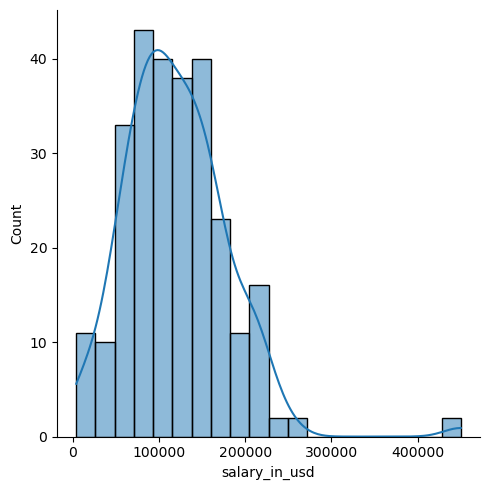

In [16]:
target = train['salary_in_usd']
sns.displot(train['salary_in_usd'], kde=True)

In [17]:
for col in train:
    print(col, train[col].nunique())

work_year 3
experience_level 4
employment_type 4
job_title 38
salary_in_usd 83
employee_residence 29
remote_ratio 3
company_location 21
company_size 3


In [18]:
train = train.drop('salary_in_usd', axis=1)
train

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
1,2022,SE,FT,Data Engineer,US,100,US,M
2,2021,MI,FT,BI Data Analyst,US,100,US,M
5,2022,MI,FT,Machine Learning Scientist,US,50,US,M
8,2022,MI,FT,Data Engineer,GR,100,GR,M
9,2021,EN,FT,Data Analyst,FR,50,FR,M
...,...,...,...,...,...,...,...,...
493,2022,SE,FT,Data Engineer,US,100,US,M
494,2022,SE,FT,Data Scientist,US,100,US,M
495,2022,SE,FT,Data Engineer,US,100,US,M
498,2021,MI,FT,Data Engineer,GB,100,GB,L


In [19]:
for col in train:
    print(col, train[col].unique())

work_year [2022 2021 2020]
experience_level ['SE' 'MI' 'EN' 'EX']
employment_type ['FT' 'FL' 'PT' 'CT']
job_title ['Data Engineer' 'BI Data Analyst' 'Machine Learning Scientist'
 'Data Analyst' 'Data Scientist' 'Research Scientist'
 'Machine Learning Developer' 'Computer Vision Engineer'
 'Lead Data Scientist' 'Machine Learning Engineer'
 'Data Analytics Manager' 'Data Specialist' 'AI Scientist'
 'Analytics Engineer' 'ETL Developer' 'Marketing Data Analyst'
 'Data Engineering Manager' 'Data Science Consultant'
 'Principal Data Analyst' 'Head of Data Science' 'Lead Data Engineer'
 'Data Architect' 'Lead Data Analyst' 'Head of Data'
 'Director of Data Science' 'Cloud Data Engineer'
 'Lead Machine Learning Engineer' 'Data Science Manager'
 'Big Data Engineer' 'Principal Data Scientist' 'Product Data Analyst'
 'Applied Machine Learning Scientist' 'Business Data Analyst'
 'Financial Data Analyst' 'Director of Data Engineering'
 'Staff Data Scientist' 'Data Analytics Engineer'
 'Computer Vis

<AxesSubplot:xlabel='work_year', ylabel='salary_in_usd'>

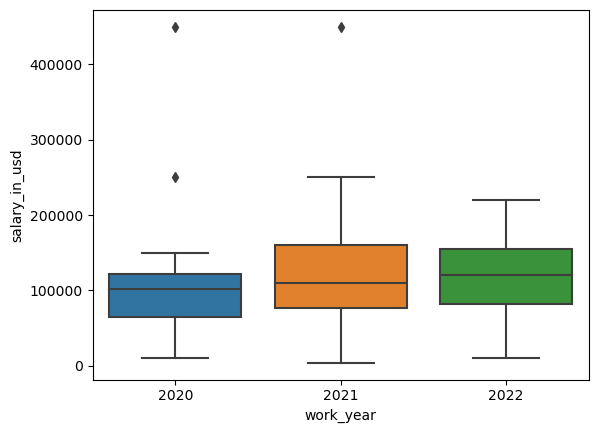

In [20]:
sns.boxplot(data=train, x="work_year", y=target)

<AxesSubplot:xlabel='experience_level', ylabel='salary_in_usd'>

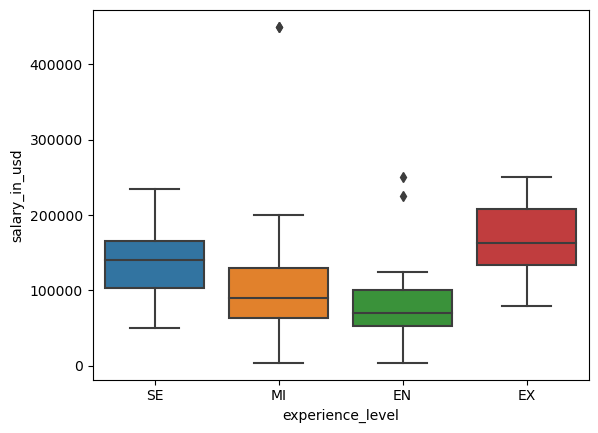

In [21]:
sns.boxplot(data=train, x="experience_level", y=target)

<AxesSubplot:xlabel='employment_type', ylabel='salary_in_usd'>

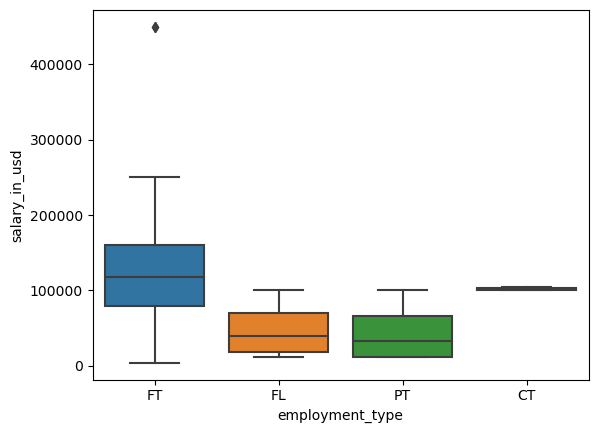

In [22]:
sns.boxplot(data=train, x="employment_type", y=target)

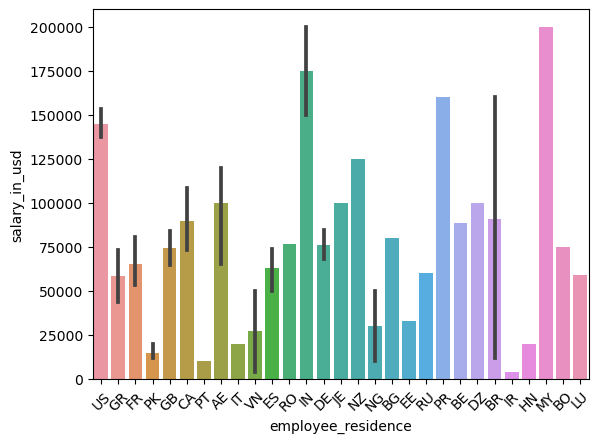

In [23]:
sns.barplot(data=train, x="employee_residence", y=target)
plt.xticks(rotation=45)
plt.show()

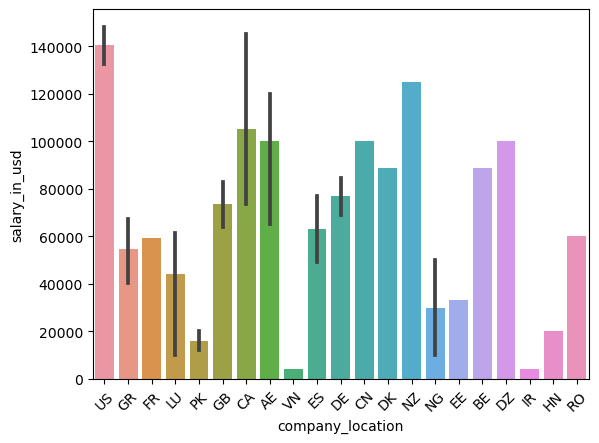

In [24]:
sns.barplot(data=train, x="company_location", y=target)
plt.xticks(rotation=45)
plt.show()

<AxesSubplot:xlabel='remote_ratio', ylabel='salary_in_usd'>

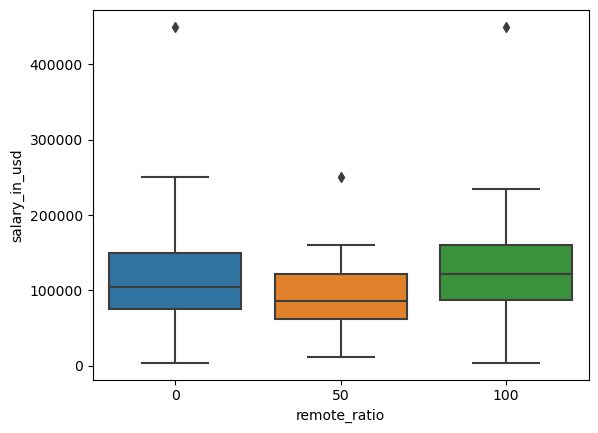

In [25]:
sns.boxplot(data=train, x="remote_ratio", y=target)

### Combine train and test

In [26]:
combi = train.append(test)
combi

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
1,2022,SE,FT,Data Engineer,US,100,US,M
2,2021,MI,FT,BI Data Analyst,US,100,US,M
5,2022,MI,FT,Machine Learning Scientist,US,50,US,M
8,2022,MI,FT,Data Engineer,GR,100,GR,M
9,2021,EN,FT,Data Analyst,FR,50,FR,M
...,...,...,...,...,...,...,...,...
102,2022,SE,FT,Data Analyst,US,100,US,M
103,2022,SE,FT,Data Architect,US,100,US,M
104,2022,SE,FT,Data Scientist,US,100,US,M
105,2022,EN,FT,Data Analyst,CA,0,CA,M


In [27]:
combi.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 378 entries, 1 to 106
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           378 non-null    int64 
 1   experience_level    378 non-null    object
 2   employment_type     378 non-null    object
 3   job_title           378 non-null    object
 4   employee_residence  378 non-null    object
 5   remote_ratio        378 non-null    int64 
 6   company_location    378 non-null    object
 7   company_size        378 non-null    object
dtypes: int64(2), object(6)
memory usage: 26.6+ KB


### Encode object columns

In [28]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()

for col in combi:
    if combi[col].dtype == 'object':
        combi[col] = enc.fit_transform(combi[col].values.reshape(-1,1))

combi

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
1,2022,3.0,2.0,13.0,42.0,100,34.0,1.0
2,2021,2.0,2.0,3.0,42.0,100,34.0,1.0
5,2022,2.0,2.0,33.0,42.0,50,34.0,1.0
8,2022,2.0,2.0,13.0,17.0,100,16.0,1.0
9,2021,0.0,2.0,9.0,15.0,50,14.0,1.0
...,...,...,...,...,...,...,...,...
102,2022,3.0,2.0,9.0,42.0,100,34.0,1.0
103,2022,3.0,2.0,12.0,42.0,100,34.0,1.0
104,2022,3.0,2.0,18.0,42.0,100,34.0,1.0
105,2022,0.0,2.0,9.0,7.0,0,5.0,1.0


### Heatmaps

<AxesSubplot:>

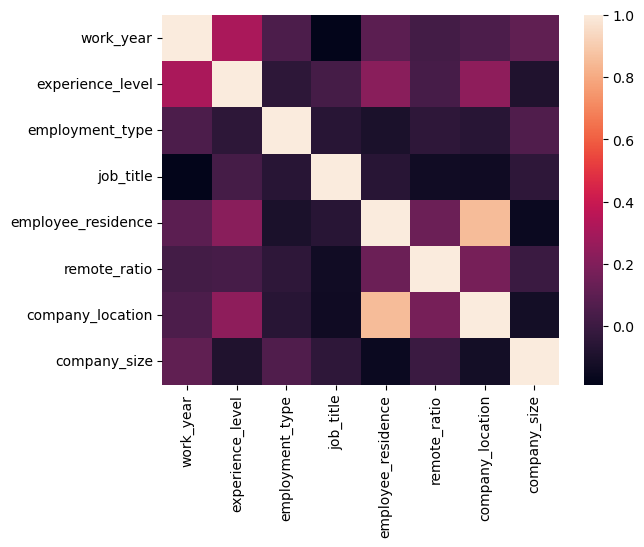

In [29]:
corr = combi.corr()
sns.heatmap(corr)

In [30]:
corr

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
work_year,1.000000,0.309277,0.050400,-0.186790,0.092403,0.024705,0.051789,0.108214
experience_level,0.309277,1.000000,-0.046658,0.029643,0.221694,0.033407,0.237385,-0.088200
employment_type,0.050400,-0.046658,1.000000,-0.057008,-0.103264,-0.042716,-0.057177,0.059662
job_title,-0.186790,0.029643,-0.057008,1.000000,-0.061549,-0.132925,-0.137836,-0.040533
employee_residence,0.092403,0.221694,-0.103264,-0.061549,1.000000,0.139476,0.854906,-0.153907
remote_ratio,0.024705,0.033407,-0.042716,-0.132925,0.139476,1.000000,0.170711,-0.003209
company_location,0.051789,0.237385,-0.057177,-0.137836,0.854906,0.170711,1.000000,-0.123644
company_size,0.108214,-0.088200,0.059662,-0.040533,-0.153907,-0.003209,-0.123644,1.000000


### Normalise data

In [31]:
combi = (combi - combi.min()) / (combi.max() - combi.min())
combi

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
1,1.0,1.000000,0.666667,0.317073,0.976744,1.0,0.971429,0.5
2,0.5,0.666667,0.666667,0.073171,0.976744,1.0,0.971429,0.5
5,1.0,0.666667,0.666667,0.804878,0.976744,0.5,0.971429,0.5
8,1.0,0.666667,0.666667,0.317073,0.395349,1.0,0.457143,0.5
9,0.5,0.000000,0.666667,0.219512,0.348837,0.5,0.400000,0.5
...,...,...,...,...,...,...,...,...
102,1.0,1.000000,0.666667,0.219512,0.976744,1.0,0.971429,0.5
103,1.0,1.000000,0.666667,0.292683,0.976744,1.0,0.971429,0.5
104,1.0,1.000000,0.666667,0.439024,0.976744,1.0,0.971429,0.5
105,1.0,0.000000,0.666667,0.219512,0.162791,0.0,0.142857,0.5


### Define X and y variables

In [32]:
y = target
X = combi[: len(train)]
X_test = combi[len(train) :]
X.shape, X_test.shape

((271, 8), (107, 8))

In [33]:
feature_len = len(X.columns)
feature_len

8

### Split dataset

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)
X_train.shape, X_val.shape, y_train.shape,y_val.shape, X_test.shape

((243, 8), (28, 8), (243,), (28,), (107, 8))

### Define model - Keras Tensorflow

In [35]:
import keras
from keras.models import Sequential
from keras.layers import Dense

In [36]:
model = Sequential()
model.add(Dense(500, input_dim=feature_len, activation= "relu"))
model.add(Dense(100, activation= "relu"))
model.add(Dense(50, activation= "relu"))
model.add(Dense(1))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 500)               4500      
                                                                 
 dense_1 (Dense)             (None, 100)               50100     
                                                                 
 dense_2 (Dense)             (None, 50)                5050      
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 59,701
Trainable params: 59,701
Non-trainable params: 0
_________________________________________________________________


In [37]:
model.compile(loss= "mean_squared_error" , optimizer="adam", metrics=["mean_squared_error"])
model.fit(X_train, y_train, epochs=2000)

Epoch 1/2000
8/8 [==============================] - 1s 4ms/step - loss: 17584515072.0000 - mean_squared_error: 17584515072.0000
Epoch 2/2000
8/8 [==============================] - 0s 4ms/step - loss: 17583806464.0000 - mean_squared_error: 17583806464.0000
Epoch 3/2000
8/8 [==============================] - 0s 4ms/step - loss: 17582182400.0000 - mean_squared_error: 17582182400.0000
Epoch 4/2000
8/8 [==============================] - 0s 4ms/step - loss: 17578467328.0000 - mean_squared_error: 17578467328.0000
Epoch 5/2000
8/8 [==============================] - 0s 3ms/step - loss: 17570990080.0000 - mean_squared_error: 17570990080.0000
Epoch 6/2000
8/8 [==============================] - 0s 3ms/step - loss: 17557295104.0000 - mean_squared_error: 17557295104.0000
Epoch 7/2000
8/8 [==============================] - 0s 4ms/step - loss: 17532741632.0000 - mean_squared_error: 17532741632.0000
Epoch 8/2000
8/8 [==============================] - 0s 4ms/step - loss: 17492385792.0000 - mean_squared_

### Predict on validation set

In [38]:
y_pred = model.predict(X_val)
y_pred[y_pred < 0] = 0
y_pred = y_pred.astype(int)

1/1 [==============================] - 0s 126ms/step


In [39]:
from sklearn.metrics import mean_squared_error
rms = np.sqrt(mean_squared_error(y_val, y_pred))
rms

61726.985708093205

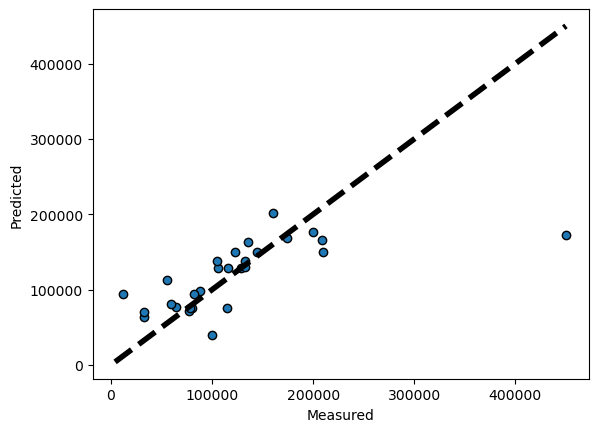

In [40]:
fig, ax = plt.subplots()
ax.scatter(y_val, y_pred, edgecolors=(0, 0, 0))
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Measured')
ax.set_ylabel('Predicted')
plt.show()

In [41]:
df_val=pd.DataFrame({'actual_value': y_val.ravel(), 'predicted_value':y_pred.ravel()})
df_val

,actual_value,predicted_value
0,115934,128474
1,135000,163054
2,79833,76118
3,87932,98509
4,450000,172386
5,12000,94155
6,160000,201811
7,63831,77302
8,106260,128474
9,100000,39950


### Predict on test set

In [42]:
predictions = model.predict(X_test)
predictions[predictions < 0] = 0
predictions = predictions.astype(int)

4/4 [==============================] - 0s 3ms/step


### Submission

In [43]:
submission['salary_in_usd'] = predictions
submission.to_csv('submission.csv', index=False)
submission = pd.read_csv("submission.csv")
submission

,id,salary_in_usd
0,0,105041
1,1,173235
2,2,133646
3,3,72912
4,4,161011
...,...,...
102,102,128474
103,103,135459
104,104,149431
105,105,18054
